In [1]:
# FUTURE INTERNS - Machine Learning Internship
# Task 2: Support Ticket Classification System

import pandas as pd                        # For loading and managing data in tables
import numpy as np                         # For numerical operations
import matplotlib.pyplot as plt            # For plotting graphs and charts
import seaborn as sns                      # For beautiful statistical visualizations
import re                                  # For regular expressions (text cleaning)
import string                              # For punctuation removal
import warnings                            # To suppress unnecessary warnings
import pickle                              # To save the trained model to a file

# NLTK: Natural Language Toolkit — used for text processing
import nltk
from nltk.corpus import stopwords          # Common words to remove (the, is, at...)
from nltk.tokenize import word_tokenize    # Splits text into individual words
from nltk.stem import WordNetLemmatizer    # Converts words to their root form

# Scikit-learn: Machine learning library
from sklearn.model_selection import train_test_split       # Split data into train/test
from sklearn.feature_extraction.text import TfidfVectorizer # Convert text to numbers
from sklearn.naive_bayes import MultinomialNB              # Naive Bayes classifier
from sklearn.linear_model import LogisticRegression        # Logistic Regression classifier
from sklearn.metrics import (
    accuracy_score,           # % of correct predictions
    classification_report,    # Precision, Recall, F1 for each class
    confusion_matrix,         # Matrix showing correct vs wrong predictions
    ConfusionMatrixDisplay     # For plotting confusion matrix nicely
)

# Download required NLTK data files (only needed once)
nltk.download('stopwords')        # List of common English stopwords
nltk.download('punkt')            # Tokenizer data
nltk.download('wordnet')          # For lemmatizer
nltk.download('omw-1.4')          # Open Multilingual WordNet (needed by lemmatizer)
nltk.download('punkt_tab')        # Additional tokenizer data

warnings.filterwarnings('ignore') # Hide unnecessary warning messages

print("✅ All libraries imported successfully!")



[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\gupta\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\gupta\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\gupta\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\gupta\AppData\Roaming\nltk_data...


✅ All libraries imported successfully!


[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\gupta\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [2]:
# Sample dataset with 40 realistic support tickets
data = {
    'ticket_text': [
        # BILLING category tickets
        "I was charged twice for my subscription this month",
        "My invoice shows wrong amount please correct it",
        "I need a refund for my recent purchase",
        "Payment failed but money was deducted from account",
        "I cannot find my billing history on the portal",
        "My credit card was charged without authorization",
        "Please update my payment method to new card",
        "I want to cancel my subscription and get refund",
        "Tax invoice not received for last month payment",
        "Double payment made please reverse one transaction",

        # TECHNICAL category tickets
        "App crashes every time I try to open it",
        "Cannot login to my account password not working",
        "Website is loading very slowly for past 2 days",
        "Error 500 showing when I submit the contact form",
        "My data is not syncing across devices",
        "The search feature is completely broken",
        "I keep getting logged out automatically",
        "Two factor authentication code not received",
        "Dashboard not showing updated statistics",
        "API integration keeps returning null values",

        # SHIPPING category tickets
        "My order has not arrived after 2 weeks",
        "Package was damaged when I received it",
        "Wrong item was delivered to my address",
        "Tracking number shows delivered but I got nothing",
        "Need to change delivery address for my order",
        "Order stuck in processing for 5 days now",
        "Shipment delayed no update on tracking page",
        "I received someone else's package by mistake",
        "Delivery attempted but I was home all day",
        "Express shipping not delivered within promised time",

        # ACCOUNT category tickets
        "I want to delete my account permanently",
        "Cannot change my email address in settings",
        "My profile picture is not updating",
        "Account suspended without any reason or notice",
        "I forgot my security questions please help",
        "Need to merge two accounts into one",
        "Username already taken but I want that specific one",
        "Account hacked please help me recover it",
        "Privacy settings not saving after I click save",
        "I need to update my phone number on account",
    ],

    'category': [
        # 10 Billing
        'Billing', 'Billing', 'Billing', 'Billing', 'Billing',
        'Billing', 'Billing', 'Billing', 'Billing', 'Billing',
        # 10 Technical
        'Technical', 'Technical', 'Technical', 'Technical', 'Technical',
        'Technical', 'Technical', 'Technical', 'Technical', 'Technical',
        # 10 Shipping
        'Shipping', 'Shipping', 'Shipping', 'Shipping', 'Shipping',
        'Shipping', 'Shipping', 'Shipping', 'Shipping', 'Shipping',
        # 10 Account
        'Account', 'Account', 'Account', 'Account', 'Account',
        'Account', 'Account', 'Account', 'Account', 'Account',
    ],

    'priority': [
        # Billing priorities
        'High', 'Medium', 'High', 'High', 'Low',
        'High', 'Low', 'Medium', 'Low', 'High',
        # Technical priorities
        'High', 'High', 'Medium', 'Medium', 'Low',
        'Medium', 'Low', 'High', 'Low', 'Medium',
        # Shipping priorities
        'High', 'High', 'High', 'High', 'Medium',
        'Medium', 'Medium', 'Low', 'Low', 'High',
        # Account priorities
        'Low', 'Low', 'Low', 'High', 'Medium',
        'Low', 'Low', 'High', 'Low', 'Low',
    ]
}

# Convert dictionary to a pandas DataFrame (like an Excel table in Python)
df = pd.DataFrame(data)

# Save the dataset to a CSV file for reference
df.to_csv('../data/tickets.csv', index=False)

print("✅ Dataset created and saved!")
print(f"\n📊 Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\n📋 First 5 rows:")
print(df.head())



✅ Dataset created and saved!

📊 Dataset Shape: 40 rows × 3 columns

📋 First 5 rows:
                                         ticket_text category priority
0  I was charged twice for my subscription this m...  Billing     High
1    My invoice shows wrong amount please correct it  Billing   Medium
2             I need a refund for my recent purchase  Billing     High
3  Payment failed but money was deducted from acc...  Billing     High
4     I cannot find my billing history on the portal  Billing      Low



📊 EXPLORATORY DATA ANALYSIS

🔍 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ticket_text  40 non-null     object
 1   category     40 non-null     object
 2   priority     40 non-null     object
dtypes: object(3)
memory usage: 1.1+ KB
None

❓ Missing Values:
ticket_text    0
category       0
priority       0
dtype: int64

📌 Category Distribution:
category
Billing      10
Technical    10
Shipping     10
Account      10
Name: count, dtype: int64

🚨 Priority Distribution:
priority
High      15
Low       15
Medium    10
Name: count, dtype: int64


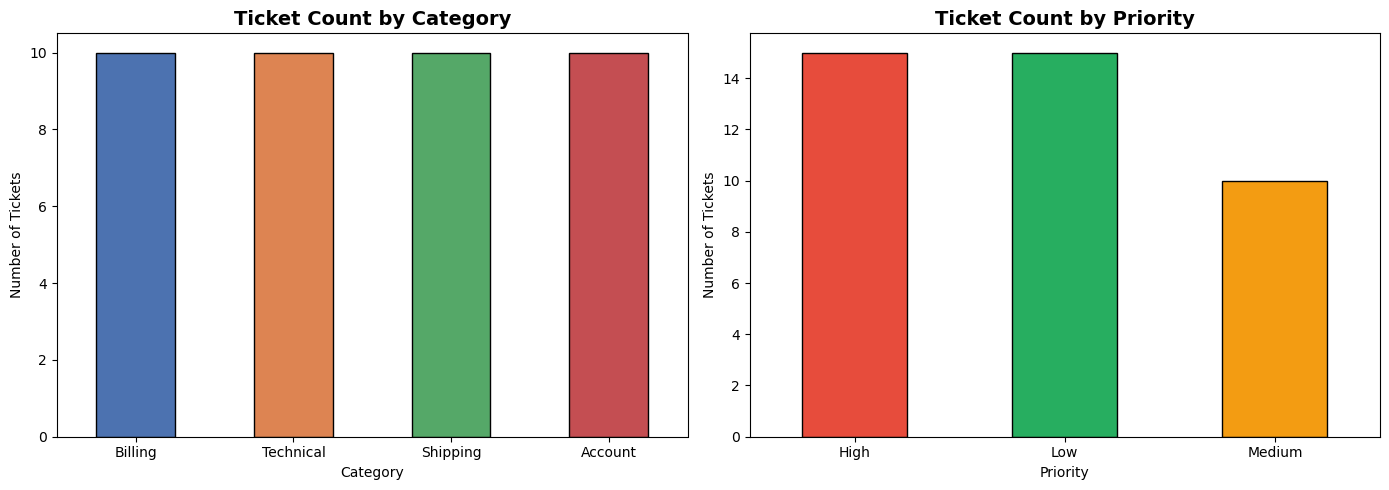

✅ EDA charts saved!


In [3]:
# EDA means: understand the data before training any model
# ============================================================

print("\n" + "="*50)
print("📊 EXPLORATORY DATA ANALYSIS")
print("="*50)

# Check basic info about the dataset
print("\n🔍 Dataset Info:")
print(df.info())

# Check for missing values (NaN = empty cells)
print("\n❓ Missing Values:")
print(df.isnull().sum())

# Count how many tickets are in each category
print("\n📌 Category Distribution:")
print(df['category'].value_counts())

# Count how many tickets have each priority
print("\n🚨 Priority Distribution:")
print(df['priority'].value_counts())

# Plot 1: Category distribution bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left chart: Category counts
df['category'].value_counts().plot(
    kind='bar',           # Bar chart type
    ax=axes[0],           # Place in left subplot
    color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'],  # Custom colors
    edgecolor='black'     # Black border on bars
)
axes[0].set_title('Ticket Count by Category', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Number of Tickets')
axes[0].tick_params(axis='x', rotation=0)  # Keep x labels horizontal

# Right chart: Priority distribution with colors
priority_colors = {'High': '#E74C3C', 'Medium': '#F39C12', 'Low': '#27AE60'}
df['priority'].value_counts().plot(
    kind='bar',
    ax=axes[1],
    color=[priority_colors[p] for p in df['priority'].value_counts().index],
    edgecolor='black'
)
axes[1].set_title('Ticket Count by Priority', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Priority')
axes[1].set_ylabel('Number of Tickets')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()         # Adjust spacing between plots
plt.savefig('../data/eda_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA charts saved!")



In [4]:
# Initialize the lemmatizer (converts: running → run, better → good)
lemmatizer = WordNetLemmatizer()

# Get the list of English stopwords (the, is, at, which, on...)
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    """
    Clean and prepare raw text for machine learning.
    
    Steps:
    1. Lowercase        → "APP Crash" becomes "app crash"
    2. Remove numbers   → "error 500" becomes "error"
    3. Remove punctuation → "can't login!" becomes "cant login"
    4. Tokenize         → "app crash" becomes ["app", "crash"]
    5. Remove stopwords → removes ["the", "is", "my", "I"]
    6. Lemmatize        → "crashes" becomes "crash"
    7. Rejoin words     → ["app", "crash"] becomes "app crash"
    """
    
    # Step 1: Convert all text to lowercase
    # "APP Crash" → "app crash"
    text = text.lower()
    
    # Step 2: Remove numbers using regex
    # "error 500" → "error "
    text = re.sub(r'\d+', '', text)
    
    # Step 3: Remove punctuation
    # "can't login!" → "cant login"
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Step 4: Tokenize — split sentence into list of words
    # "app crash now" → ["app", "crash", "now"]
    tokens = word_tokenize(text)
    
    # Step 5: Remove stopwords AND very short words (length < 2)
    # ["i", "cannot", "login", "the"] → ["cannot", "login"]
    tokens = [word for word in tokens 
              if word not in stop_words and len(word) > 2]
    
    # Step 6: Lemmatize each word (get root form)
    # ["crashes", "running"] → ["crash", "run"]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    
    # Step 7: Join tokens back into a single string
    # ["app", "crash"] → "app crash"
    return ' '.join(tokens)


# Apply the preprocessing function to every ticket in the dataset
# This creates a new column 'cleaned_text' with the processed version
df['cleaned_text'] = df['ticket_text'].apply(preprocess_text)

print("✅ Text preprocessing complete!")
print("\n📝 Before vs After Preprocessing:")
print("-" * 60)
for i in range(3):   # Show first 3 examples
    print(f"ORIGINAL : {df['ticket_text'][i]}")
    print(f"CLEANED  : {df['cleaned_text'][i]}")
    print("-" * 60)


✅ Text preprocessing complete!

📝 Before vs After Preprocessing:
------------------------------------------------------------
ORIGINAL : I was charged twice for my subscription this month
CLEANED  : charged twice subscription month
------------------------------------------------------------
ORIGINAL : My invoice shows wrong amount please correct it
CLEANED  : invoice show wrong amount please correct
------------------------------------------------------------
ORIGINAL : I need a refund for my recent purchase
CLEANED  : need refund recent purchase
------------------------------------------------------------


In [5]:
# Initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    max_features=500,    # Keep only top 500 most important words
    ngram_range=(1, 2),  # Use single words AND pairs of words (bigrams)
                         # Example: "not working" counts as one feature
    min_df=1,            # Word must appear in at least 1 document
    sublinear_tf=True    # Apply log scaling to term frequency
)

# Fit the vectorizer on cleaned text and transform it to numbers
# X = feature matrix (rows = tickets, columns = word scores)
X = tfidf.fit_transform(df['cleaned_text'])

# Target labels
y_category = df['category']   # What we want to predict (Billing, Technical...)
y_priority = df['priority']   # Priority level (High, Medium, Low)

print(f"✅ TF-IDF Feature Extraction complete!")
print(f"📐 Feature Matrix Shape: {X.shape}")
print(f"   → {X.shape[0]} tickets × {X.shape[1]} features (words)")
print(f"\n🏷️  Unique Categories: {y_category.unique()}")
print(f"🚨 Unique Priorities : {y_priority.unique()}")



✅ TF-IDF Feature Extraction complete!
📐 Feature Matrix Shape: (40, 288)
   → 40 tickets × 288 features (words)

🏷️  Unique Categories: ['Billing' 'Technical' 'Shipping' 'Account']
🚨 Unique Priorities : ['High' 'Medium' 'Low']


In [6]:
# Split for CATEGORY classification
X_train, X_test, y_cat_train, y_cat_test = train_test_split(
    X,                  # Feature matrix (TF-IDF numbers)
    y_category,         # Target labels (Billing, Technical...)
    test_size=0.2,      # 20% data goes to test set
    random_state=42,    # Seed for reproducibility
    stratify=y_category # Ensure equal distribution of categories in both sets
)

# Split for PRIORITY classification (same X, different y)
_, _, y_pri_train, y_pri_test = train_test_split(
    X,
    y_priority,
    test_size=0.2,
    random_state=42,
    stratify=y_priority
)

print(f"✅ Data Split Complete!")
print(f"   Training samples : {X_train.shape[0]}")
print(f"   Testing  samples : {X_test.shape[0]}")


✅ Data Split Complete!
   Training samples : 32
   Testing  samples : 8


In [7]:
# Naive Bayes works well for text classification because:
# - It's fast even with large datasets
# - Works well with word frequency data (TF-IDF)
# - Good accuracy with small datasets
# - MultinomialNB is designed specifically for word counts
# ============================================================

print("\n" + "="*50)
print("🤖 MODEL 1: NAIVE BAYES")
print("="*50)

# --- Category Classification ---
nb_cat = MultinomialNB(alpha=1.0)  # alpha=1.0 is Laplace smoothing
nb_cat.fit(X_train, y_cat_train)   # Train the model on training data
nb_cat_pred = nb_cat.predict(X_test)  # Predict on test data

# Calculate accuracy
nb_cat_acc = accuracy_score(y_cat_test, nb_cat_pred)
print(f"\n📌 Category Classification Accuracy: {nb_cat_acc:.2%}")
print("\n📊 Detailed Report:")
print(classification_report(y_cat_test, nb_cat_pred))

# --- Priority Classification ---
nb_pri = MultinomialNB(alpha=1.0)
nb_pri.fit(X_train, y_pri_train)
nb_pri_pred = nb_pri.predict(X_test)

nb_pri_acc = accuracy_score(y_pri_test, nb_pri_pred)
print(f"🚨 Priority Classification Accuracy: {nb_pri_acc:.2%}")
print("\n📊 Detailed Report:")
print(classification_report(y_pri_test, nb_pri_pred))



🤖 MODEL 1: NAIVE BAYES

📌 Category Classification Accuracy: 75.00%

📊 Detailed Report:
              precision    recall  f1-score   support

     Account       0.50      1.00      0.67         2
     Billing       1.00      0.50      0.67         2
    Shipping       1.00      1.00      1.00         2
   Technical       1.00      0.50      0.67         2

    accuracy                           0.75         8
   macro avg       0.88      0.75      0.75         8
weighted avg       0.88      0.75      0.75         8

🚨 Priority Classification Accuracy: 62.50%

📊 Detailed Report:
              precision    recall  f1-score   support

        High       0.50      1.00      0.67         3
         Low       1.00      0.67      0.80         3
      Medium       0.00      0.00      0.00         2

    accuracy                           0.62         8
   macro avg       0.50      0.56      0.49         8
weighted avg       0.56      0.62      0.55         8



In [8]:
# Logistic Regression works well because:
# - Usually more accurate than Naive Bayes
# - Can understand relationships between features
# - Good for multiclass classification
# - max_iter=1000 ensures the model converges properly
# ============================================================

print("\n" + "="*50)
print("🤖 MODEL 2: LOGISTIC REGRESSION")
print("="*50)

# --- Category Classification ---
lr_cat = LogisticRegression(
    max_iter=1000,        # Maximum iterations to find best parameters
    C=1.0,                # Regularization strength (higher = less regularization)
    solver='lbfgs',       # Optimization algorithm
    multi_class='auto'    # Automatically handles multiple categories
)
lr_cat.fit(X_train, y_cat_train)
lr_cat_pred = lr_cat.predict(X_test)

lr_cat_acc = accuracy_score(y_cat_test, lr_cat_pred)
print(f"\n📌 Category Classification Accuracy: {lr_cat_acc:.2%}")
print("\n📊 Detailed Report:")
print(classification_report(y_cat_test, lr_cat_pred))

# --- Priority Classification ---
lr_pri = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs')
lr_pri.fit(X_train, y_pri_train)
lr_pri_pred = lr_pri.predict(X_test)

lr_pri_acc = accuracy_score(y_pri_test, lr_pri_pred)
print(f"🚨 Priority Classification Accuracy: {lr_pri_acc:.2%}")
print("\n📊 Detailed Report:")
print(classification_report(y_pri_test, lr_pri_pred))




🤖 MODEL 2: LOGISTIC REGRESSION

📌 Category Classification Accuracy: 87.50%

📊 Detailed Report:
              precision    recall  f1-score   support

     Account       0.67      1.00      0.80         2
     Billing       1.00      0.50      0.67         2
    Shipping       1.00      1.00      1.00         2
   Technical       1.00      1.00      1.00         2

    accuracy                           0.88         8
   macro avg       0.92      0.88      0.87         8
weighted avg       0.92      0.88      0.87         8

🚨 Priority Classification Accuracy: 50.00%

📊 Detailed Report:
              precision    recall  f1-score   support

        High       0.67      0.67      0.67         3
         Low       0.40      0.67      0.50         3
      Medium       0.00      0.00      0.00         2

    accuracy                           0.50         8
   macro avg       0.36      0.44      0.39         8
weighted avg       0.40      0.50      0.44         8




📊 MODEL COMPARISON


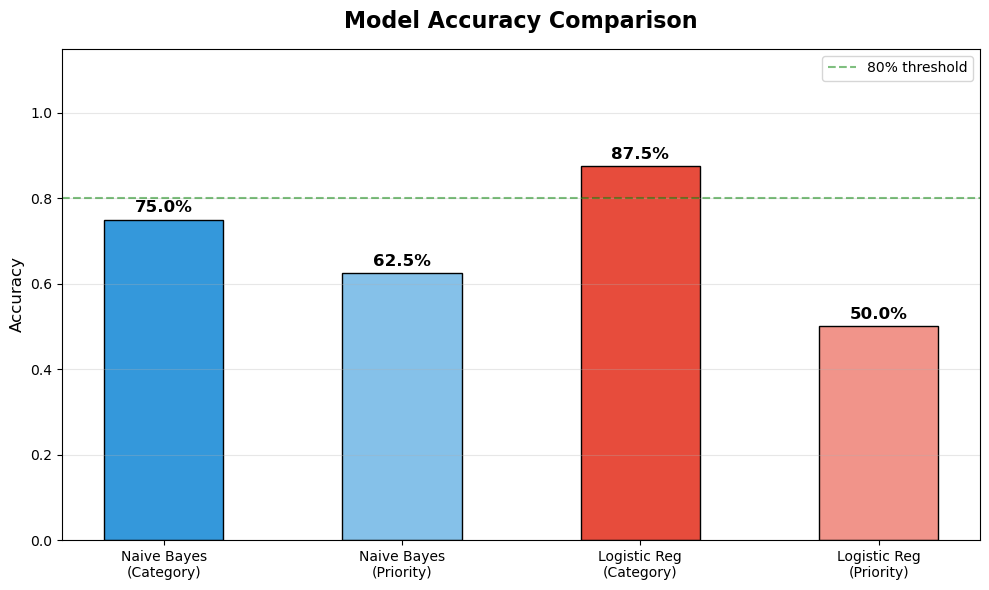

✅ Comparison chart saved!


In [9]:
print("\n" + "="*50)
print("📊 MODEL COMPARISON")
print("="*50)

# Data for comparison chart
models = ['Naive Bayes\n(Category)', 'Naive Bayes\n(Priority)',
          'Logistic Reg\n(Category)', 'Logistic Reg\n(Priority)']
accuracies = [nb_cat_acc, nb_pri_acc, lr_cat_acc, lr_pri_acc]
colors = ['#3498DB', '#85C1E9', '#E74C3C', '#F1948A']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(models, accuracies, color=colors, edgecolor='black', width=0.5)

# Add accuracy percentage labels on top of each bar
for bar, acc in zip(bars, accuracies):
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # X position: center of bar
        bar.get_height() + 0.01,             # Y position: just above bar
        f'{acc:.1%}',                         # Format: "85.0%"
        ha='center',                          # Horizontal alignment
        va='bottom',                          # Vertical alignment
        fontsize=12,
        fontweight='bold'
    )

ax.set_title('Model Accuracy Comparison', fontsize=16, fontweight='bold', pad=15)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_ylim(0, 1.15)  # Y axis from 0 to 115% to give room for labels
ax.axhline(y=0.8, color='green', linestyle='--', alpha=0.5, label='80% threshold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../data/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Comparison chart saved!")



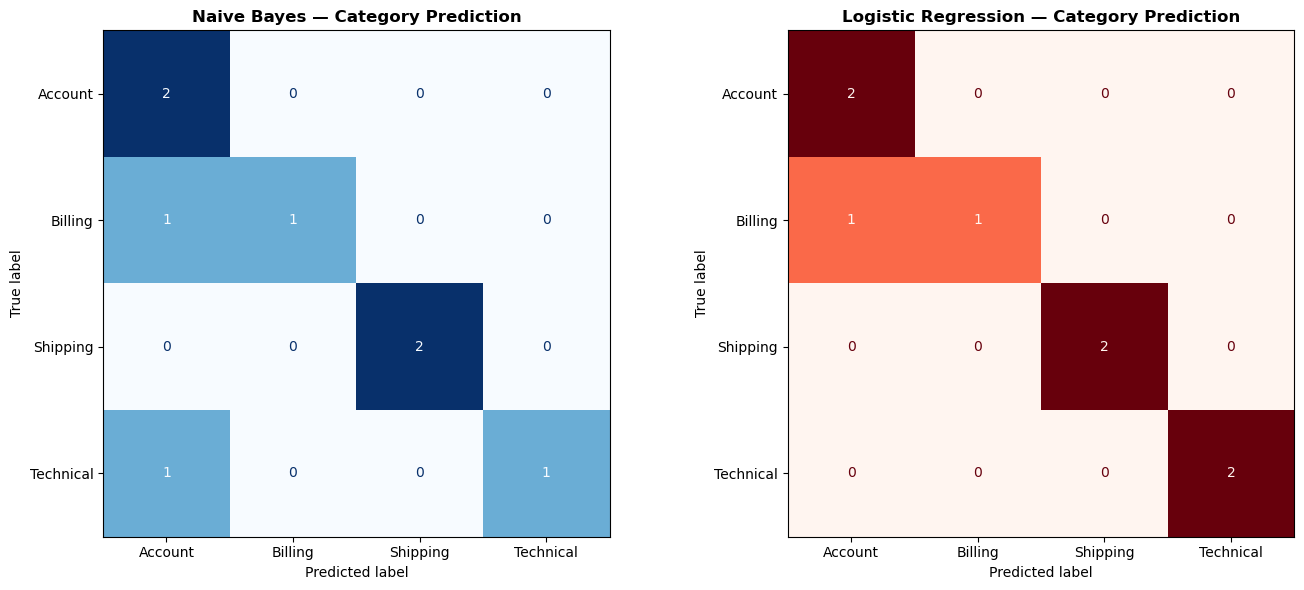

✅ Confusion matrices saved!


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Naive Bayes confusion matrix for categories
cm_nb = confusion_matrix(y_cat_test, nb_cat_pred)
disp_nb = ConfusionMatrixDisplay(
    confusion_matrix=cm_nb,
    display_labels=nb_cat.classes_
)
disp_nb.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Naive Bayes — Category Prediction', fontsize=12, fontweight='bold')

# Right: Logistic Regression confusion matrix for categories
cm_lr = confusion_matrix(y_cat_test, lr_cat_pred)
disp_lr = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=lr_cat.classes_
)
disp_lr.plot(ax=axes[1], cmap='Reds', colorbar=False)
axes[1].set_title('Logistic Regression — Category Prediction', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrices saved!")



In [11]:
# We save the trained models so we don't need to retrain
# pickle = converts Python objects to files that can be reloaded
# ============================================================

# Save best category model (Logistic Regression usually performs better)
with open('../model/category_model.pkl', 'wb') as f:
    pickle.dump(lr_cat, f)

# Save best priority model
with open('../model/priority_model.pkl', 'wb') as f:
    pickle.dump(lr_pri, f)

# Save the TF-IDF vectorizer (MUST save this too!)
# Without it, we cannot transform new text the same way
with open('../model/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print("✅ Models saved to ../model/ folder!")
print("   category_model.pkl    — Logistic Regression for category")
print("   priority_model.pkl    — Logistic Regression for priority")
print("   tfidf_vectorizer.pkl  — TF-IDF vectorizer")



✅ Models saved to ../model/ folder!
   category_model.pkl    — Logistic Regression for category
   priority_model.pkl    — Logistic Regression for priority
   tfidf_vectorizer.pkl  — TF-IDF vectorizer


In [12]:
# This is the final working system!
# Give it any new ticket text and it predicts:
# 1. Category (Billing / Technical / Shipping / Account)
# 2. Priority (High / Medium / Low)
# ============================================================

def classify_ticket(ticket_text):
    """
    Given a new support ticket text, predict its category and priority.
    
    Args:
        ticket_text (str): Raw support ticket text from customer
        
    Returns:
        dict: Dictionary with 'category' and 'priority' predictions
    """
    
    # Step 1: Clean the input text using our preprocessing function
    cleaned = preprocess_text(ticket_text)
    
    # Step 2: Convert cleaned text to TF-IDF numbers
    # transform() uses the vocabulary already learned during fit_transform()
    features = tfidf.transform([cleaned])
    
    # Step 3: Predict category and priority
    category = lr_cat.predict(features)[0]   # [0] gets first (only) result
    priority = lr_pri.predict(features)[0]
    
    # Step 4: Get confidence probabilities for each class
    cat_proba = lr_cat.predict_proba(features)[0]
    cat_classes = lr_cat.classes_
    
    return {
        'ticket': ticket_text,
        'cleaned': cleaned,
        'category': category,
        'priority': priority,
        'confidence': {cls: f"{prob:.1%}" for cls, prob in zip(cat_classes, cat_proba)}
    }


# Test with 5 new tickets never seen by the model
print("\n" + "="*55)
print("🎯 LIVE TICKET CLASSIFICATION DEMO")
print("="*55)

test_tickets = [
    "My payment was deducted twice from my bank account",
    "The mobile app keeps freezing and wont open properly",
    "My package shows delivered but it never arrived",
    "I need to update my email address in profile settings",
    "I want a refund for the damaged product I received"
]

for ticket in test_tickets:
    result = classify_ticket(ticket)
    
    # Choose emoji based on priority
    priority_emoji = {'High': '🔴', 'Medium': '🟡', 'Low': '🟢'}
    
    print(f"\n📩 Ticket  : {result['ticket']}")
    print(f"🏷️  Category: {result['category']}")
    print(f"{priority_emoji[result['priority']]} Priority : {result['priority']}")
    print(f"📊 Confidence: {result['confidence']}")
    print("-" * 55)

print("\n✅ Ticket Classification System is working perfectly!")
print("\n🎉 Task 2 Complete! : FUTURE_ML_02")



🎯 LIVE TICKET CLASSIFICATION DEMO

📩 Ticket  : My payment was deducted twice from my bank account
🏷️  Category: Billing
🔴 Priority : High
📊 Confidence: {'Account': '24.3%', 'Billing': '35.5%', 'Shipping': '19.1%', 'Technical': '21.0%'}
-------------------------------------------------------

📩 Ticket  : The mobile app keeps freezing and wont open properly
🏷️  Category: Technical
🟡 Priority : Medium
📊 Confidence: {'Account': '21.6%', 'Billing': '21.9%', 'Shipping': '22.0%', 'Technical': '34.5%'}
-------------------------------------------------------

📩 Ticket  : My package shows delivered but it never arrived
🏷️  Category: Shipping
🟢 Priority : Low
📊 Confidence: {'Account': '19.0%', 'Billing': '21.1%', 'Shipping': '40.0%', 'Technical': '19.9%'}
-------------------------------------------------------

📩 Ticket  : I need to update my email address in profile settings
🏷️  Category: Account
🔴 Priority : High
📊 Confidence: {'Account': '43.7%', 'Billing': '17.7%', 'Shipping': '20.4%', 'Tech